In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
)
import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd
from pathlib import Path


from src.data_models.caravanify import Caravanify, CaravanifyConfig

from src.data_models.datamodule import HydroDataModule

from sklearn.pipeline import Pipeline

from src.preprocessing.grouped import GroupedTransformer

# from src.preprocessing.log_scale import LogTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

from src.model_evaluation.evaluators import TSForecastEvaluator
from src.models.tide import LitTiDE, TiDEConfig

---

In [3]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)


caravan = Caravanify(config)
ids_for_training = caravan.get_all_gauge_ids()[:10]

path_to_hii = "/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv"

ids_for_training, _ = caravan.filter_gauge_ids_by_human_influence(
    ids_for_training, ["Low", "Medium"]
)

caravan.load_stations(ids_for_training)
static_data = caravan.get_static_attributes()
ts_data = caravan.get_time_series()

Original gauge_ids: 10
Filtered gauge_ids: 10


In [4]:
ts_columns = [
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "streamflow",
    "temperature_2m_mean",
    "total_precipitation_sum",
]

ts_columns_to_keep = ts_columns + ["gauge_id", "date"]
ts_data = ts_data[ts_columns_to_keep]

In [5]:
static_columns = [
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

static_columns_to_keep = static_columns + ["gauge_id"]

static_data = static_data[static_columns_to_keep]

In [6]:
forcing_features = [
    col for col in ts_columns if col not in ["gauge_id", "date", "streamflow"]
]

target_feature = "streamflow"

---

In [7]:
feature_pipeline = Pipeline(
    [
        # ("log", LogTransformer(columns=dynamic_feature_cols)),
        ("scaler", StandardScaleTransformer(columns=forcing_features)),
    ]
)

# Target pipeline: grouped by basin with log + scale
target_pipeline = GroupedTransformer(
    Pipeline(
        [
            # ("log", LogTransformer(columns=target_cols)),
            ("scaler", StandardScaleTransformer(columns=[target_feature])),
        ]
    ),
    columns=[target_feature],
    group_identifier="gauge_id",
    n_jobs=-1,
)

# Static feature pipeline: just scaling
static_pipeline = Pipeline(
    [("scaler", StandardScaleTransformer(columns=static_columns))]
)

# Define preprocessing configurations
preprocessing_configs = {
    "features": {"pipeline": feature_pipeline, "columns": ts_columns},
    "target": {"pipeline": target_pipeline, "columns": [target_feature]},
    "static_features": {"pipeline": static_pipeline, "columns": static_columns},
}

---

In [ ]:
output_length = 10
input_length = 40

data_module = HydroDataModule(
    time_series_df=ts_data,
    static_df=static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_configs,
    batch_size=256,
    input_length=input_length,
    output_length=output_length,
    num_workers=4,
    features=ts_columns,
    static_features=static_columns,
    target="streamflow",
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    domain_id="CA",
    use_proportional_split=True,
    max_imputation_gap_size=2,
)

data_module.prepare_data()
data_module.setup(stage="fit")

Original basins: 10
Retained basins: 7
Domain CH (source): Created 27995 valid sequences from 7 catchments
Domain CH (source): Created 13600 valid sequences from 7 catchments


---

In [9]:
config = TiDEConfig(
    input_len=input_length,
    output_len=output_length,
    input_size=len(ts_columns) - 1,
    future_input_size=len(ts_columns) - 1,
    static_size=len(static_columns),
    num_encoder_layers=2,
    num_decoder_layers=2,
    decoder_output_size=16,
    hidden_size=16,
    temporal_decoder_hidden_size=16,
    past_feature_projection_size=4,
    future_forcing_projection_size=4,
    use_layer_norm=True,
    dropout=0.1,
    learning_rate=1e-3,
)

# Instantiate the Lightning module.
model = LitTiDE(config)

In [10]:
model

LitTiDE(
  (mse_criterion): MSELoss()
  (model): TiDEModel(
    (encoder): Sequential(
      (0): TiDEResBlock(
        (dense): Sequential(
          (0): Linear(in_features=250, out_features=16, bias=True)
          (1): ReLU()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
        (skip): Linear(in_features=250, out_features=16, bias=True)
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
      (1): TiDEResBlock(
        (dense): Sequential(
          (0): Linear(in_features=16, out_features=16, bias=True)
          (1): ReLU()
          (2): Linear(in_features=16, out_features=16, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
        (skip): Linear(in_features=16, out_features=16, bias=True)
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (decoder): Sequential(
      (0): TiDEResBlock(
        (dense): Sequential

In [11]:
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="cpu",
    devices=1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, mode="min"),
        LearningRateMonitor(logging_interval="epoch"),
    ],
)

# Train the model
trainer.fit(model, data_module)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 10
Retained basins: 7



  | Name          | Type      | Params | Mode 
----------------------------------------------------
0 | mse_criterion | MSELoss   | 0      | train
1 | model         | TiDEModel | 17.1 K | train
----------------------------------------------------
17.1 K    Trainable params
0         Non-trainable params
17.1 K    Total params
0.069     Total estimated model params size (MB)
61        Modules in train mode
0         Modules in eval mode


Domain CH (source): Created 27995 valid sequences from 7 catchments
Domain CH (source): Created 13600 valid sequences from 7 catchments


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [12]:
models_and_datamodules = {
    "TiDE": (model, data_module),
}

evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

In [13]:
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing TiDE...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 10
Retained basins: 7
Domain CH (source): Created 13695 valid sequences from 7 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.12505081295967102
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Predictions shape: torch.Size([13695, 10])
Observations shape: torch.Size([13695, 10])
Number of basin_ids: 13695
Number of input_end_dates: 13695
Configured horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Evaluating results with shape: preds=(13695, 10), obs=(13695, 10), basin_ids=(13695,)


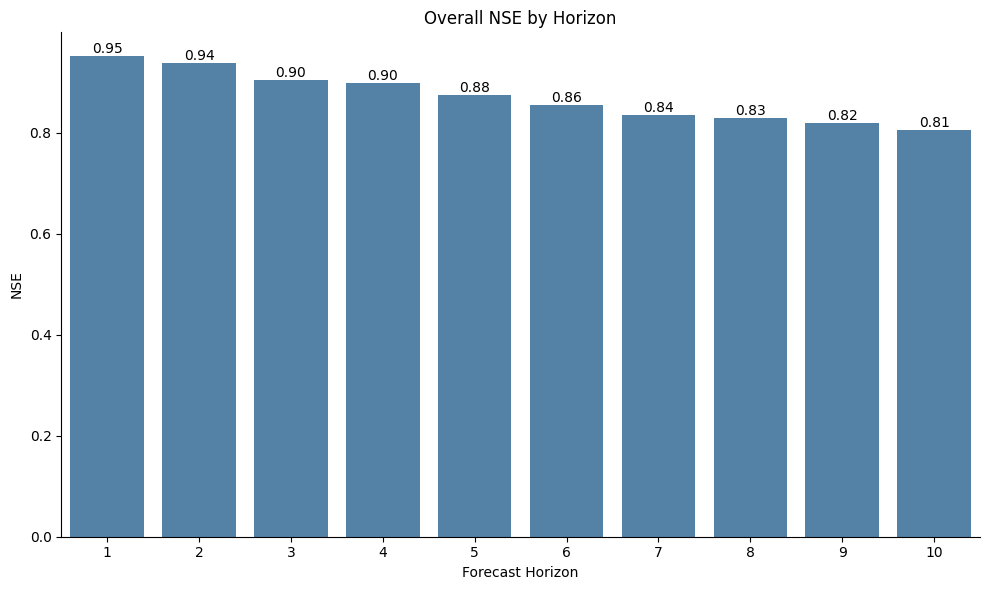

In [14]:
overall_summary = evaluator.summarize_metrics(results["TiDE"]["metrics"])


def plot_metric_summary(
    summary_df: pd.DataFrame, metric: str, per_basin: bool = False, figsize=(10, 6)
):
    plt.figure(figsize=figsize)

    if per_basin:
        df_plot = summary_df[metric].unstack(level=0)

        # Sort basins based on first horizon values
        first_horizon_values = df_plot.iloc[0]
        sorted_basins = first_horizon_values.sort_values(ascending=False).index
        df_plot = df_plot[sorted_basins]

        sns.barplot(
            data=df_plot.melt(ignore_index=False).reset_index(),
            x="horizon",
            y="value",
            hue="basin_id",
            palette="Blues",
        )
        plt.title(f"{metric} by Basin and Horizon")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Basin ID")

    else:
        ax = sns.barplot(x=summary_df.index, y=summary_df[metric], color="steelblue")
        plt.title(f"Overall {metric} by Horizon")

        for i, v in enumerate(summary_df[metric]):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

    plt.xlabel("Forecast Horizon")
    plt.ylabel(metric)
    plt.tight_layout()
    sns.despine()
    plt.show()


# Plot overall NSE
plot_metric_summary(
    overall_summary,
    metric="NSE",
    per_basin=False,
    figsize=(10, 6),
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '1-day Forecast for CA_15044'}, xlabel='Date', ylabel='Streamflow'>)

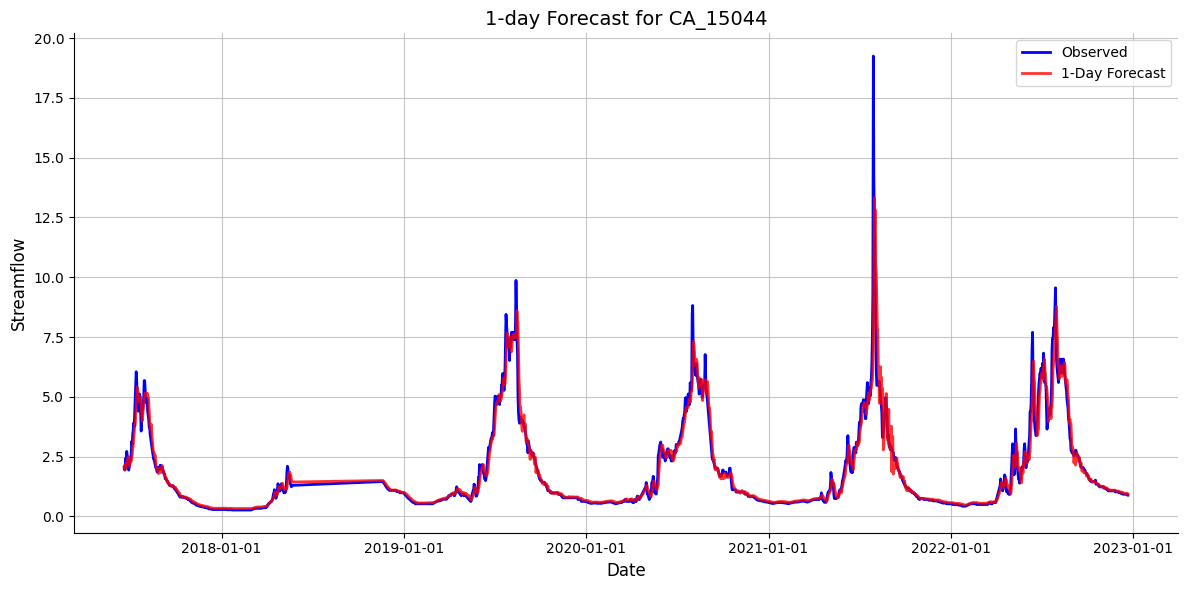

In [15]:
evaluator.plot_rolling_forecast("TiDE", horizon=1, group_identifier="CA_15044")